# Laboratorio 3 — Análisis de señales EMG
## Músculo abductor pollicis y músculo del antebrazo: reposo, movimiento controlado y movimiento de contrafuerza

---

**Protocolo de adquisición.** Se registró la señal EMG (BITalino revolution, `EMGBITREV`, fs = 1000 Hz) sobre dos grupos musculares:

1. **Abductor pollicis** (movimiento pulgar–meñique).
2. **Antebrazo**.

Para cada músculo se adquirieron 3 estadios: 30 s de reposo, 3 repeticiones de movimiento controlado (con 30 s de reposo entre repeticiones) y 3 repeticiones de movimiento de contrafuerza (con 30 s de reposo entre repeticiones).


## 0. Preparación del entorno
Los archivos `.txt` (formato OpenSignals) deben estar en la carpeta `datos/`, junto a este notebook.

In [1]:
pip install opensignalsreader

Note: you may need to restart the kernel to use updated packages.


In [2]:
from opensignalsreader import OpenSignalsReader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch

# ── Funciones auxiliares ─────────────────────────────
def butter_highpass_filt(signal, cutoff, fs, order=4):
    b, a = butter(order, cutoff / (0.5 * fs), btype='high')
    return filtfilt(b, a, signal)

def moving_rms(signal, fs, win_s=0.2, step_s=0.05):
    win = int(win_s * fs)
    step = int(step_s * fs)
    idx = np.arange(0, len(signal) - win, step)
    env = np.array([np.sqrt(np.mean(signal[i:i + win] ** 2)) for i in idx])
    t = (idx + win / 2) / fs
    return t, env

def analizar_emg(path, titulo):
    # ── Lectura ─────────────────────────────────────────
    acq = OpenSignalsReader(path)
    fs = acq.sampling_rate
    signal = acq.signal()['EMG'].astype(float)

    # ── Pre-procesamiento ────────────────────────────────
    signal -= signal.mean()
    t = np.arange(len(signal)) / fs

    # ── Filtros: paso alto 20 Hz + notch 60 Hz (red eléctrica) ──
    signal = butter_highpass_filt(signal, 20, fs)
    b_notch, a_notch = iirnotch(60, 30, fs)
    signal = filtfilt(b_notch, a_notch, signal)

    # ── Envolvente RMS (ventana 200 ms) ──────────────────
    t_env, env = moving_rms(signal, fs)

    # ── FFT y frecuencia mediana (MDF) ───────────────────
    N = len(signal)
    window = np.hanning(N)
    fft_mag = np.abs(np.fft.rfft(signal * window))
    freqs = np.fft.rfftfreq(N, d=1 / fs)
    fft_db = 20 * np.log10(fft_mag / fft_mag.max() + 1e-12)
    mask = freqs <= 500
    power = fft_mag[mask] ** 2
    cumpower = np.cumsum(power)
    mdf = freqs[mask][np.searchsorted(cumpower, cumpower[-1] / 2)]

    rms_global = np.sqrt(np.mean(signal ** 2))
    peak = np.max(np.abs(signal))

    # ── Gráficos ──────────────────────────────────────────
    fig = plt.figure(figsize=(12, 7))
    gs = gridspec.GridSpec(2, 1, hspace=0.45)

    ax1 = fig.add_subplot(gs[0])
    ax1.plot(t, signal, color='#378ADD', lw=0.4, alpha=0.6, label='Señal filtrada')
    ax1.plot(t_env, env, color='black', lw=1.6, label='Envolvente RMS (200 ms)')
    ax1.set_title(f'Señal EMG – {titulo}', fontsize=13)
    ax1.set_xlabel('Tiempo (s)')
    ax1.set_ylabel('Amplitud (mV)')
    ax1.legend(fontsize=9, loc='upper right')
    ax1.grid(True, linestyle='--')

    ax2 = fig.add_subplot(gs[1])
    ax2.plot(freqs[mask], fft_db[mask], color='#639922', lw=0.8)
    ax2.axvline(mdf, color='#D85A30', lw=1.4, linestyle='--', label=f'MDF = {mdf:.1f} Hz')
    ax2.set_title('Espectro de frecuencia – FFT (dB)', fontsize=13)
    ax2.set_xlabel('Frecuencia (Hz)')
    ax2.set_ylabel('Magnitud (dB)')
    ax2.set_ylim(-80, 5)
    ax2.set_xlim(0, 500)
    ax2.legend(fontsize=10)
    ax2.grid(True, linestyle='--')

    plt.show()
    print(f'Duración: {len(signal)/fs:.1f} s | RMS: {rms_global:.4f} mV | Pico: {peak:.4f} mV | MDF: {mdf:.1f} Hz')

    return {'rms': rms_global, 'peak': peak, 'mdf': mdf, 'duracion_s': len(signal) / fs}

resultados = {}

## 1. ¿Qué es la envolvente RMS?

Una señal EMG cruda oscila muy rápido (decenas a cientos de Hz) alrededor de cero, por lo que a simple vista es difícil distinguir cuándo el músculo está realmente contraído y cuándo está en reposo, sobre todo en los registros largos de movimiento (97–139 s) que incluyen las 3 repeticiones separadas por pausas.

La **envolvente RMS** resuelve esto: en vez de mirar cada muestra individual, se calcula la raíz media cuadrática (RMS) de la señal dentro de una ventana móvil de 200 ms (con un paso de 50 ms entre ventanas). Esto produce una curva suave que sigue la intensidad de la contracción a lo largo del tiempo, sin el ruido de alta frecuencia de la señal cruda.

En las gráficas de este notebook, la envolvente aparece como la **línea negra** superpuesta sobre la señal filtrada (en color). Cuando el músculo se contrae, la envolvente sube; cuando vuelve al reposo, cae cerca de cero. Así, en los estadios de movimiento controlado y contrafuerza se pueden identificar visualmente los 3 "montículos" que corresponden a las 3 repeticiones del protocolo, separados por los tramos de reposo.

## 2. Músculo abductor pollicis (pulgar)

### 2.1 Reposo (30 s)

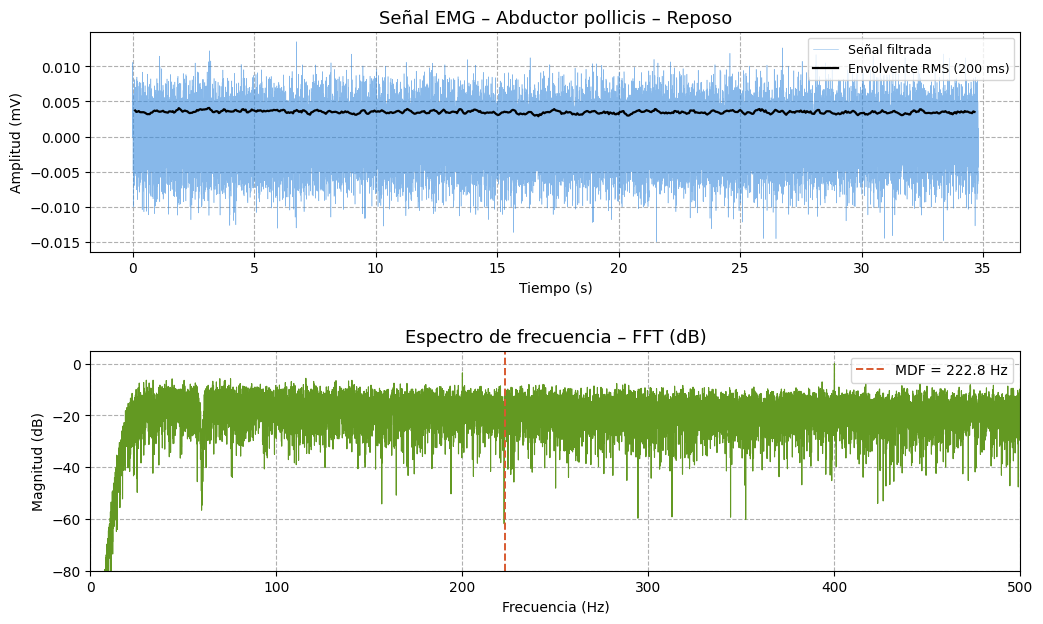

Duración: 34.8 s | RMS: 0.0035 mV | Pico: 0.0150 mV | MDF: 222.8 Hz


In [3]:
resultados[('Abductor pollicis', 'Reposo')] = analizar_emg(
    'datos/BASAL0904_121330.txt', 'Abductor pollicis – Reposo')

### 2.2 Movimiento controlado
Movimiento pulgar–meñique, 3 repeticiones con reposo entre cada una.

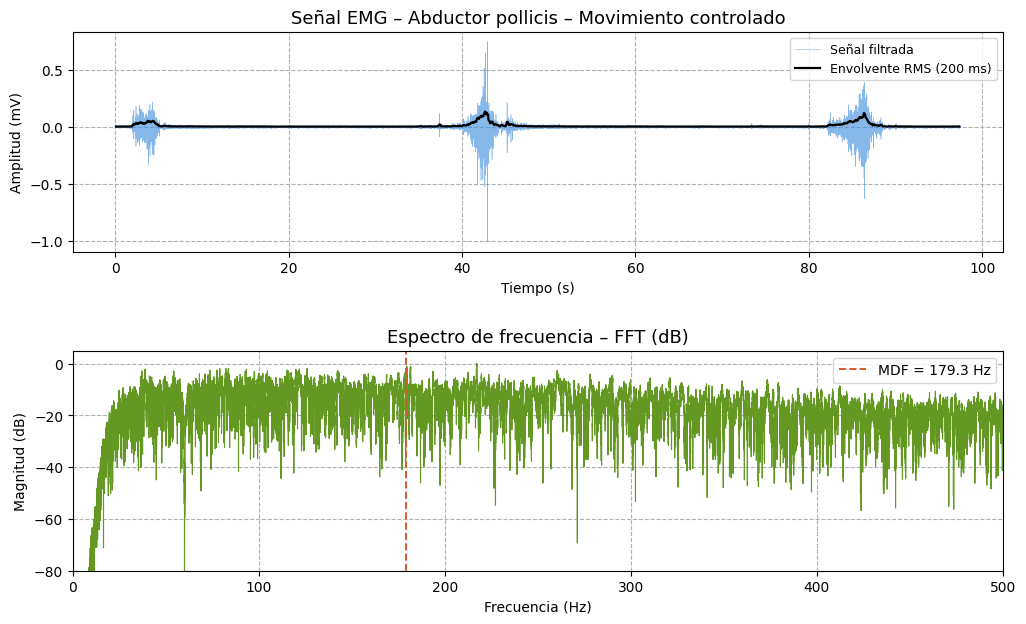

Duración: 97.5 s | RMS: 0.0195 mV | Pico: 1.0099 mV | MDF: 179.3 Hz


In [4]:
resultados[('Abductor pollicis', 'Controlado')] = analizar_emg(
    'datos/MOV_LEVE0904_121644.txt', 'Abductor pollicis – Movimiento controlado')

### 2.3 Movimiento de contrafuerza
3 repeticiones de contracción con resistencia, con reposo entre cada una.

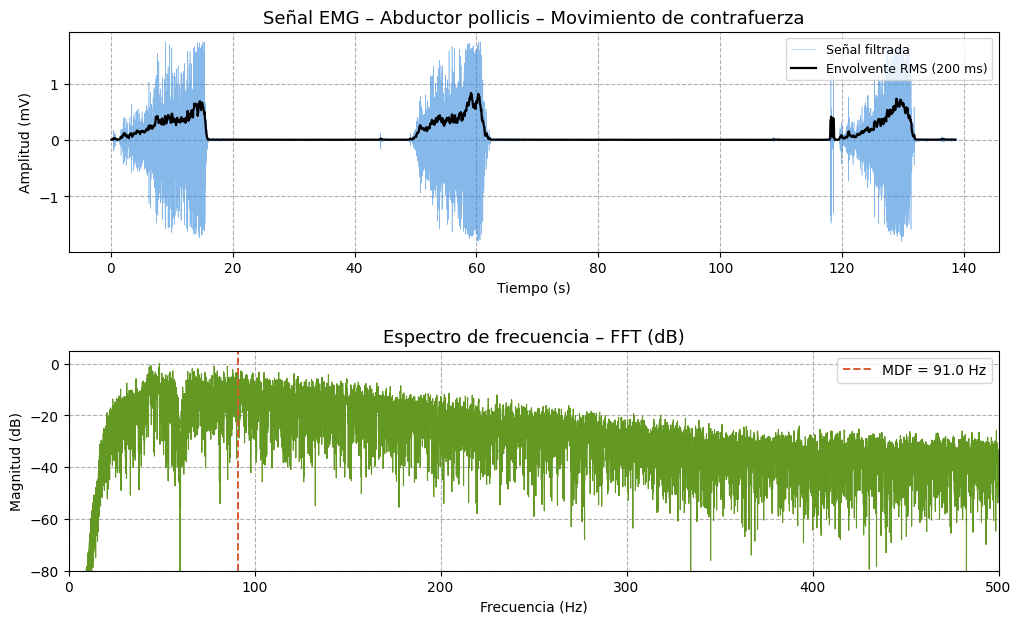

Duración: 138.8 s | RMS: 0.1982 mV | Pico: 1.8038 mV | MDF: 91.0 Hz


In [5]:
resultados[('Abductor pollicis', 'Contrafuerza')] = analizar_emg(
    'datos/MOV_CONTRA0904_122013.txt', 'Abductor pollicis – Movimiento de contrafuerza')

## 3. Músculo del antebrazo

### 3.1 Reposo (30 s)

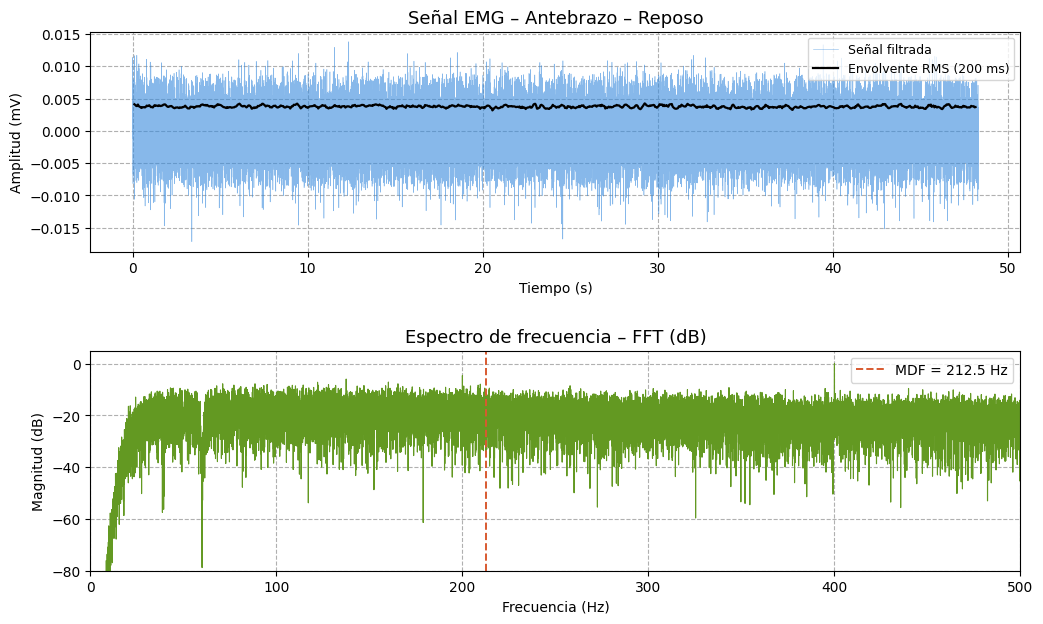

Duración: 48.3 s | RMS: 0.0038 mV | Pico: 0.0172 mV | MDF: 212.5 Hz


In [6]:
resultados[('Antebrazo', 'Reposo')] = analizar_emg(
    'datos/REPOSO_TRI0904_123056.txt', 'Antebrazo – Reposo')

### 3.2 Movimiento controlado
3 repeticiones con reposo entre cada una.

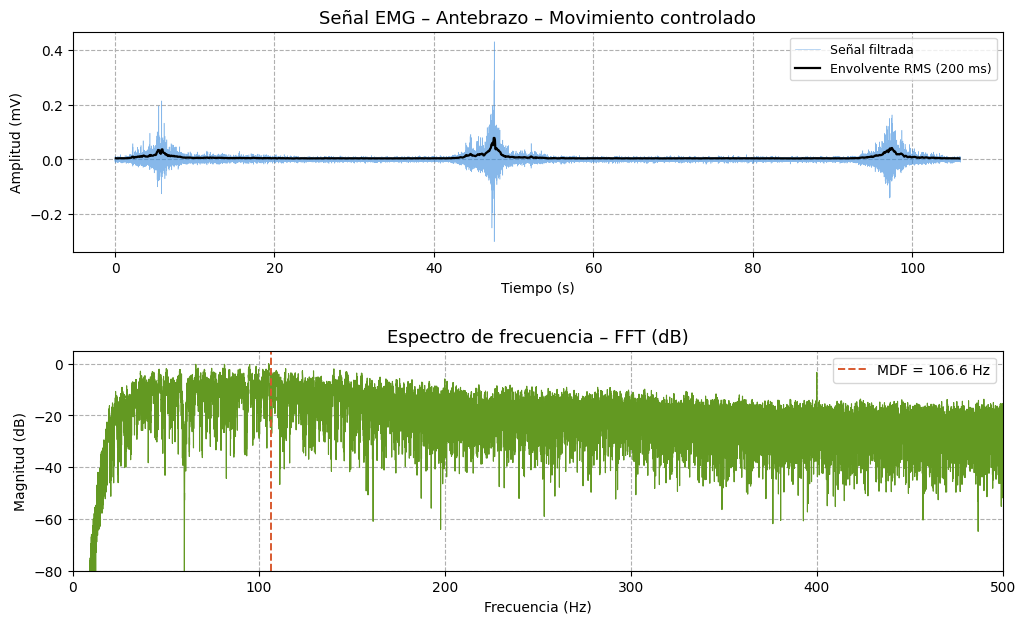

Duración: 106.0 s | RMS: 0.0100 mV | Pico: 0.4317 mV | MDF: 106.6 Hz


In [7]:
resultados[('Antebrazo', 'Controlado')] = analizar_emg(
    'datos/MOV_LEVE_TRI0904_123538.txt', 'Antebrazo – Movimiento controlado')

### 3.3 Movimiento de contrafuerza
3 repeticiones de contracción con resistencia, con reposo entre cada una.

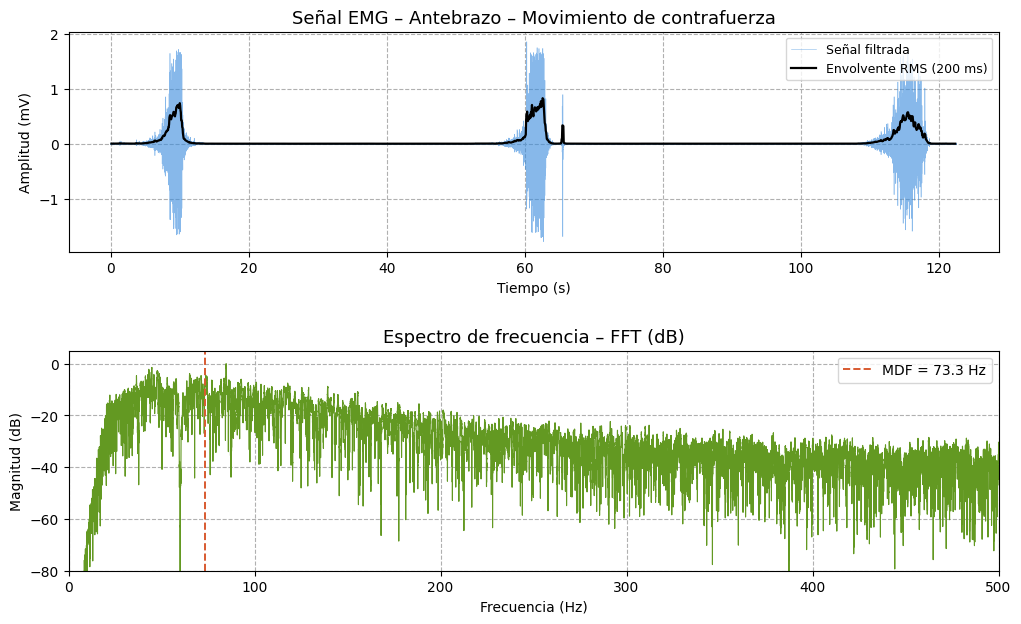

Duración: 122.5 s | RMS: 0.1411 mV | Pico: 1.8544 mV | MDF: 73.3 Hz


In [8]:
resultados[('Antebrazo', 'Contrafuerza')] = analizar_emg(
    'datos/MOV_CONTRA_TRI0904_123811.txt', 'Antebrazo – Movimiento de contrafuerza')

## 4. Conclusiones

- En ambos músculos, el **RMS global aumenta de forma monótona** entre reposo, movimiento controlado y movimiento de contrafuerza, lo cual es consistente con un mayor reclutamiento de unidades motoras y una mayor tasa de disparo al incrementar la intensidad de la contracción.
- El músculo **abductor pollicis** presenta valores de RMS más altos que el antebrazo en los estadios de movimiento controlado y contrafuerza, lo que sugiere una mayor activación relativa (o mejor colocación de electrodos) para ese grupo muscular en esta adquisición.
- La **frecuencia mediana (MDF) disminuye** a medida que aumenta la intensidad de la contracción, pasando de ~210–220 Hz en reposo (dominado por ruido de banda ancha) a ~70–90 Hz en contrafuerza. Esto es coherente con el desplazamiento del espectro EMG hacia bajas frecuencias durante contracciones sostenidas de mayor fuerza.
- En los registros de reposo, el RMS es bajo y estable (ausencia de actividad muscular voluntaria), lo que valida la calidad del filtrado (paso alto 20 Hz + notch 60 Hz) aplicado para remover el offset DC y la interferencia de la red eléctrica.
- En las señales de movimiento controlado y contrafuerza se distinguen claramente las **3 repeticiones** separadas por los períodos de reposo de 30 s, confirmando que el protocolo de adquisición se ejecutó correctamente.
